# Interim Monthly Primary Productivity (NetPP) Algorithm
> History | Updated Dec 2024

## Background

**Net primary productivity in the ocean is the rate at which phytoplankton store energy as biomass and make it available to other consumers in an ecosystem.**

* It is typically reported in units like mg C/m2/day

* It is driven by photosynthesis where phytoplankton use light energy to convert $\text{CO}_2$ into organic carbon.

**Productivity measurements happen in the field, usually on a research cruise.**

* Water is collected at several depths in the water column.

* The water is spiked with radiolabeled C ($C^{14}$), and incubated over a range of light levels for 24 hours.

* The rate of radiolabeled C ending up in pythoplankton cells is used to determine net primary productivity.

**The 1997 Behrenfeld and Falkowski algorithm estimates primary productivity using satellite measurements.**

* The algorithm uses three satellite measurements:

    * chlorophyll_a (Chl) https://en.wikipedia.org/wiki/Chlorophyll_a

    * sea surface temperature (SST)

    * photosynthetically active radiation (PAR) https://en.wikipedia.org/wiki/Photosynthetically_active_radiation

* The type of model is called a Vertically Generalized Production Model (VGPM). https://en.wikipedia.org/wiki/Vertically_Generalized_Production_Model

### **The algorithm formulation is listed below:**

> $PP_{eu} = 0.66125 \times P_{opt}^b \times \frac{PAR^o}{PAR^o + 4.1} \times Z_{eu} \times CHL \times DL$
>
> ### Where:

* CHL = chlorophyll a concentration at surface (mg m^-3)
* DL = Daylight hours - (hours)
* $Z_{eu}$ = the depth where light is 1% of that at the surface - Units: meters (m)
* $P_{opt}^b$ Maximum C fixation rate within the water column - Units: mg C (mg Chl)-1 h-1
* PAR = Photosynthetically Active Radiation - Units: Daily average insitu par (Einstein m-2 d-1)

### Several of these parameters can be determined with satellite data

$P_{opt}^b$ is derived from SST using the seventh order polynomial of Behrenfeld and Falkowski (1997).

> $P_{opt}^b = -3.27E-8 \cdot T^7 + 3.4132E-6 \cdot T^6 - 1.348E-4 \cdot T^5 + 2.462E-3 \cdot T^4 - 0.0205 \cdot T^3 + 0.0617 \cdot T^2 + 0.2749 \cdot T$

* Where T = temperature in Celsius (℃)


$Z_{eu}$ is derived from an estimate of the total chlorophyll concentration within the euphotic layer ($CHL_{eu}$) based on the Case I models of Morel and Berthon (1989):

> $Z_{eu} = 568.2 \cdot CHL^{-0.746} \quad \text{when } CHL_{eu} > 10.0$
>
> or
>
> $Z_{eu} = 200.0 \cdot CHL^{-0.293} \quad \text{when } CHL_{eu} \leq 10.0$

> Where:
>
> - $CHL_{eu} = 38.0 \cdot CHL^{0.4250} \quad \text{when } CHL \leq 1.0$
> - or
> - $CHL_{eu} = 40.2 \cdot CHL^{0.5070} \quad \text{when } CHL > 1.0$

## Objectives
Create primary productivity satellite-based products.

This script generates primary productivity fields from chlorophyll, SST, PAR
satellite data using the method of Behrenfeld and Falkowski 1997. It accepts
source satellite data that has been gridded to the NASA 9km SMI.
NOAA CoastWatch standard ocean color grid. As written, the script is tailored
for pairing the following global, monthly input data to produce
primary productivity fields:
* **NASA NOAA20-VIIRS chlorophyll and PAR**
* **SST frome the NOAA Gridded Super-collated product**

Users set the satellite input data, start dates and stop date
via command-line arguments.

The output files are created by generating a template netCDF file from a cdl
file that is prepopulate with metadata but has only latitude and longitude
data. The template file is populated with the primary productivity data
and then renamed.

The script can be repurposed for different input data with these modifications:

* Gridding any input chlorophyll, PAR, and SST data to a common grid

* Creating an appropriate cdl file for the dataset

* Adjusting the logic to make directory paths

* Adjust output file naming and input file search pattern.

> ### **Steps:**
>
> **Directory Setup**
>
> * Ensure all required directories are created dynamically based on the input parameters.
>
> **Download Data**
>
> * Download CHL, PAR, and SST data.
>
> **NetPP Calculations**
>
> * Load datasets (CHL, PAR, SST).
>
> * Calculate:
>   * $P_{opt}^b$ : Chlorophyll-specific productivity.
>
>   * $Z_{eu}$ : Euphotic depth.
>
>   * DL: Daylength.
>      
>   * NetPP using the Behrenfeld-Falkowski algorithm.
>
> **Save NetPP Output**
>
> * Generate a NetCDF file for each date, populated with calculated fields and metadata.
>
> * Compress the NetCDF file and move it to the target directory.
>
> **Visualize the NetPP data**
> 
> * Create global plots of NetPP, SST, CHL, & PAR
>
> * Plot $P_{opt}^b$ as a function of SST

### Resource Requirements

* Jupyter Notebook.

* Python 3 with the modules included within the "Import packages" section below.

* Template CDL file that is prepopulated with metadata but has only latitude and longitude data.

* Internet connection.

* NASA Earth Data Credentials?

## Import packages

In [1]:
from calendar import monthrange
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt

%matplotlib inline
import numpy.ma as ma
import numpy as np
import os
import subprocess
import pandas as pd
import xarray as xr
from netCDF4 import Dataset
from datetime import datetime, timezone
import sys
from dateutil.parser import parse
import warnings

warnings.filterwarnings("ignore")

## Create global variables

Global variables are used to set up the file structure, directory paths, and template files required for processing NetPP.

In [2]:
# Create your global variables
ROOT_DIR = "/Users/madisonrichardson/netpp"
CHL_DIR_T = os.path.join(ROOT_DIR, "data/{}/chl/monthly_chl")
PAR_DIR_T = os.path.join(ROOT_DIR, "data/{}/par/monthly_par")
SST_DIR_T = os.path.join(ROOT_DIR, "data/{}/sst/monthly_sst")
WORK_DIR = os.path.join(ROOT_DIR, "work")
BIN_DIR = os.path.join(ROOT_DIR, "bin")
RES_DIR = os.path.join(ROOT_DIR, "resources")
NC_OUT_DIR_T = os.path.join(ROOT_DIR, "data/{}/netpp/monthly_netpp")
# Add the ncgen input cdl and output nc file names
CDL_IN_FILE = "MonthlyNetpp.cdl"
TEMP_OUT_FILE = "temp_out_file.nc"

## Create useful functions

### Downloads chlorophyll or PAR data from NASA for the specified date and sensor

In [3]:
def download_nasa_data(date, data_type, directory):
    """Download NASA data files.

    Downloads chlorophyll and PAR data from
    L3 NOAA20-VIIRS on NASA data search website.

    Args_:
        date (datetime): The date format %Y-%m-%d for which the data is
                        downloaded.
        data_type (str): The type of data to download, either
                        'chlorophyll' or 'par'.
        directory (str): The directory where the downloaded data will be saved.

    Raises_:
        ValueError: If the 'data_type is not 'chlorophyll' or 'par'.
    """

    dtid = "1197"
    if data_type == "chlorophyll":
        prod_id = "chlor_a"
        product_prefix = "CHL"
    elif data_type == "par":
        prod_id = "par"
        product_prefix = "PAR"
    else:
        raise ValueError("data_type must be chlorophyll or par")

    wget_template = " ".join(
        [
            "wget",
            "-q",
            '--post-data="results_as_file=1&sensor_id=33&dtid={}&sdate={}&edate={}',
            '&subType=1&addurl=1&prod_id={}&resolution_id=9km&period=MO"',
            "-O {}",
            "https://oceandata.sci.gsfc.nasa.gov/api/file_search",
        ]
    )

    sdate = date.strftime("%Y-%m-%d 00:00:00")
    edate = date.strftime("%Y-%m-%d 23:59:59")

    # File name for list of files
    file_list_name = f"{data_type}_nasa_file_list" f'{date.strftime("%Y%m")}.txt'
    file_list_path = os.path.join(directory, file_list_name)

    # Format wget command for retrieving file list
    nasa_wget = wget_template.format(dtid, sdate, edate, prod_id, file_list_path)

    subprocess.call(nasa_wget, shell=True)

    df = pd.read_csv(file_list_path, names=["wget_url"])
    files = list(df.wget_url)
    file_url = next((ln for ln in files if "NRT" not in ln), "default_value")

    # Debugging output: Print full wget command and the dates
    print(f"Start Date: {sdate}")
    print(f"End Date: {edate}")
    print(f"Generated wget command: {nasa_wget}")

    # Command to download file
    myCmd_template = " ".join(
        [
            "wget",
            "--load-cookies ~/.urs_cookies",
            "--save-cookies ~/.urs_cookies",
            "--auth-no-challenge=on",
            "--content-disposition",
            "-P {}",
            "{}",
        ]
    )
    subprocess.call(myCmd_template.format(directory, file_url), shell=True)

    # Verify downloaded file exists
    downloaded_file_name = os.path.basename(file_url)
    downloaded_file_path = os.path.join(directory, downloaded_file_name)

    if os.path.exists(downloaded_file_path):
        print(
            f"Downloaded {data_type} data for"
            f"{date.strftime("%Y%m")} to"
            f"{downloaded_file_path}"
        )

        # Make new filename in YYYYMM format
        new_file_name = f"JPSS1_VIIRS.{date.strftime("%Y%m")}.L3m.MO.{product_prefix}.{prod_id}.9km.nc"
        new_file_path = os.path.join(directory, new_file_name)

        # Rename downloaded file
        os.rename(downloaded_file_path, new_file_path)

        print(f"Renamed file to: {new_file_path}")

    else:
        print(f"Failed to download {data_type} data for" f"{date.strftime("%Y%m")}")

### Calculates maximum chlorophyll-specific productivity ($P_{opt}^b$) using a 7th order polynomial

In [4]:
def calculate_PbOpt(sst_data_mod):
    """Calculate the maximum chlorophyll fixation rate.

    Calculates the maximum chlorophyll fixation rate (PbOpt) within the
    water column based on modified SST data using a seventh-order
    polynomial equation.

    Args_:
        sst_data_mod (ndarray or float): Modified SST where SST < -1 equal
            to the value at -1 and to set all values where SST > 29 equal to
            the value at 29. This can either be a single value or a numpy
            array of SST values.

    Returns_:
        ndarray or float: The calculated maximum chlorophyll fixation rate
                        (PbOpt) (units: mg C (mg chl)^-1 h^-1) corresponding
                        to the input SST data. The return matches the input
                        data meaning if a single value is inputted, a float
                        is returned, or if the input is an array, a numpy
                        array is returned.

    """
    return (
        -3.27e-8 * sst_data_mod**7
        + 3.4132e-6 * sst_data_mod**6
        - 1.348e-4 * sst_data_mod**5
        + 2.462e-3 * sst_data_mod**4
        - 0.0205 * sst_data_mod**3
        + 0.0617 * sst_data_mod**2
        + 0.2749 * sst_data_mod
        + 1.2956
    )

### Computes euphotic depth ($Z_{eu}$) based on chlorophyll concentration

In [5]:
def calculate_Z_eu(chl):
    """Calculate the euphotic depth.

    Calculates the euphotic depth where light is 1% of that at the surface
    (Z_eu) based on chlorophyll-a concentration (CHL_eu) using the Case I
    models of Morel and Berthon (1989).

    Args_:
        chl (xarray.DataArray or ndarray): Chlorophyll-a concentration
                                                (mg m^-3). The input can be
                                                either an xarray.DataArray or
                                                a numpy array.

    Return_:
        xarray.DataArray or ndarray: The calculated euphotic depth (Z_eu) in
                                    meters, where the return type matches the
                                    input type.

    """
    chl_eu = ma.where(chl > 1.0, 40.2 * chl**0.5070, 38.0 * chl**0.4250)

    Z_eu = ma.where(chl_eu > 10.0, 568.2 * chl_eu**-0.746, 200.0 * chl_eu**-0.293)

    return Z_eu

### Computes daylight hours (DL) based on latitude and 16th day of the month

In [6]:
def daylength_month(month, lat):
    """Determine the length of the daylight period for a given month.

    Computes the length of the day (the time between sunrise and
    sunset) for the middle day of the month (16th day) given
    the latitude of the location.
    Function uses the Brock model for the computations.
    For more information see, for example,
    Forsythe et al., "A model comparison for daylength as a
    function of latitude and day of year", Ecological Modelling,
    1995. Modified (vectorize) from by Dale Robinson:
    https://gist.github.com/anttilipp/ed3ab35258c7636d87de6499475301ce


    Args:
        month (int): The month of the year, where 1 corresponds to January
        and 12 corresponds to December.
        lat (ndarray): A numpy array of latitude of the pixel
        location in decimal degrees. Positive values for north and negative
        for south.


    Returns:
        day_len (ndarray): A numpy array of daylength in decimal hours,
        e.g., 12:30pm is 12.5.
    """

    # Define the approximate day of the year for the 16th day of each month
    dayOfYear_month = {
        1: 16,
        2: 47,
        3: 75,
        4: 106,
        5: 136,
        6: 167,
        7: 197,
        8: 228,
        9: 259,
        10: 289,
        11: 320,
        12: 350,
    }

    # Get the approximate day of the year for the 16th day of the given month
    dayOfYear = dayOfYear_month.get(month, 16)

    # Correct for leap year
    if dayOfYear == 366:
        dayOfYear = 365

    latInRad = np.deg2rad(lat)
    declinationOfEarth = 23.45 * np.sin(np.deg2rad(360.0 * (283.0 + dayOfYear) / 365.0))

    cos_hour_angle = -np.tan(latInRad) * np.tan(np.deg2rad(declinationOfEarth))
    cos_hour_angle = np.clip(cos_hour_angle, -1.0, 1.0)

    hourAngle = np.rad2deg(np.arccos(cos_hour_angle))

    day_len = 2.0 * hourAngle / 15.0
    day_len = np.where(cos_hour_angle <= -1.0, 24, day_len)
    day_len = np.where(cos_hour_angle >= 1.0, 0, day_len)

    return day_len

### Calculates NetPP ($PP_{eu}$)based on input variables

In [7]:
def calculate_PPeu(chl, Pbopt, Z_eu, par_squeeze, day_len_2d):
    """Calculate the daily depth-integrated primary production.

    Calculates the daily depth-integrated primary production (PP_eu) using
    a Vertically Generalized Production Model (VGPM).

    Args_:
        chl (xarray.DataArray or ndarray): Chlorophyll-a concentration
            (mg m^-3).
        Pbopt (xarray.DataArray or ndarray): Maximum chlorophyll fixation rate
            (PbOpt) (mg C (mg chl)^-1 h^-1).
        Z_eu (xarray.DataArray or ndarray): Euphotic depth (Z_eu) in meters.
        par_squeeze (xarray.DataArray or ndarray): Photosynthetically ACtive
        Radiation (PAR) (Einstein m^-2 d^-1).
        day_len_2d (xarray.DataArray or ndarray): Length of the daylight
            period expanded into a 2D array to match the dimensions
            of the other inputs.

    Returns_:
        xarray.DataArray or ndarray: The calculated primary production (PP_eu)
            (mg C m^-2 d^-1), with the return type matching the input types.

    """
    par_ratio = par_squeeze / (par_squeeze + 4.1)
    PPeu = 0.66125 * Pbopt * par_ratio * Z_eu * chl * day_len_2d
    return PPeu

## Input Parameters and Metadata

* Define the input parameters such as start and end dates, sensor type (NOAA20), overwrite settings, and metadata (current timestamp and sensor-specific information).

* Validates that the start date is earlier than the end date.

In [8]:
# Parameters
start_date = "2018-01-01"
end_date = "2018-01-31"
sensor = "noaa20"
overwrite = True  # Change to True if you want to overwrite existing NetCDF file

# Parse the start and end dates
start_date = parse(start_date)
end_date = parse(end_date)

# Current timestamp for metadata
now = datetime.now()

# Dictionary for added metadata
end_year = {"noaa20": "2017"}

# Validate date range
if start_date > end_date:
    sys.exit("start date must be < end date")

## Create directories dynamically based on the input parameters

* Ensure that all necessary directories exist, and if they do not, they are created.

* Dynamically determines paths based on the year range and sensor type.

In [9]:
# Create directories for all years between start_date and end_date
for year in range(start_date.year, end_date.year + 1):
    # Create dynamic directories based on sensor and year range
    CHL_DIR = os.path.join(CHL_DIR_T.format(sensor), str(year))
    PAR_DIR = os.path.join(PAR_DIR_T.format(sensor), str(year))
    SST_DIR = os.path.join(SST_DIR_T.format(sensor))
    NC_OUT_DIR = os.path.join(NC_OUT_DIR_T.format(sensor))

DIR_LIST = [ROOT_DIR, WORK_DIR, CHL_DIR, PAR_DIR, SST_DIR, NC_OUT_DIR]

for dr in DIR_LIST:
    os.makedirs(dr, exist_ok=True)
print(len(DIR_LIST), "directories validated")

6 directories validated


## Main Processing Loop for Getting NetPP

The primary loop that processes each date in the range and performs the following tasks:

1. Initializes variables and file paths.

2. Downloads required chlorophyll, PAR, and SST data for the current date.

3. Loads the datasets and calculates netPP components.

4. Saves the netPP results to a NetCDF file and compresses the output.

In [10]:
# Initialize the processing loop
current_date = start_date

while current_date <= end_date:
    print("Processing this date", current_date)

    # Define the output NetCDF file anf file path for the current date
    formatted_date = current_date.strftime("%Y%m")
    nc_filename = f"productivity_month_{sensor}_{formatted_date}_9km.nc"
    odir = os.path.join(NC_OUT_DIR, str(current_date.year))
    os.makedirs(odir, exist_ok=True)
    nc_file_path = os.path.join(odir, nc_filename)

    # Add logic to not overwrite existing files unless overwrite = True
    if os.path.isfile(nc_file_path):
        if not overwrite:
            print(nc_filename, "already exists")
            current_date += relativedelta(months=1)
            continue
        else:
            print("overwriting", nc_filename)

    # Set timestamp for NetCDF metadata
    middle_of_month = current_date.replace(
        day=16, hour=12, minute=0, second=0, tzinfo=timezone.utc
    )
    timestamp = middle_of_month.timestamp()

    # Download NASA chlorophyll and par data
    try:
        download_nasa_data(current_date, "chlorophyll", CHL_DIR)
        download_nasa_data(current_date, "par", PAR_DIR)
    except Exception as e:
        print("One or more of hte NASA files did not download", e)
        current_date += relativedelta(months=1)
        continue

    # Load chlorophyll, par, and sst datasets
    chl_file = os.path.join(
        CHL_DIR, f"JPSS1_VIIRS.{formatted_date}.L3m.MO.CHL.chlor_a.9km.nc"
    )
    par_file = os.path.join(
        PAR_DIR, f"JPSS1_VIIRS.{formatted_date}.L3m.MO.PAR.par.9km.nc"
    )
    sst_file = os.path.join(SST_DIR, f"sst_leo_9km_{formatted_date}_monthly.nc")

    sst_ds = Dataset(sst_file, "r")
    chl_ds = Dataset(chl_file, "r")
    par_ds = Dataset(par_file, "r")

    sst = sst_ds["sea_surface_temperature"][0, :, :]
    sst = sst - 273.15
    chl = chl_ds["chlor_a"][:, :]
    par = par_ds["par"][:, :]
    latitudes = chl_ds["lat"][:]
    longitudes = chl_ds["lon"][:]

    sst_ds.close()
    chl_ds.close()
    par_ds.close()

    lon_grid, lat_grid = np.meshgrid(longitudes, latitudes)

    # Mask all sst values < -2
    sst = ma.masked_where(sst < -2, sst)

    # Adjust sst values outside of range
    sst_data_mod = ma.where(sst < -1, -1, sst)
    sst_data_mod = ma.where(sst_data_mod > 29, 29, sst_data_mod)
    print(
        "sst_data_mod made", sst_data_mod.min(), sst_data_mod.max(), sst_data_mod.shape
    )

    # Calculate PbOPt and verify
    PbOpt = calculate_PbOpt(sst_data_mod)
    print("PbOpt made", PbOpt.min(), PbOpt.max())

    sst_list = np.arange(-1, 30, 1)

    PbOpt_plot = (
        -3.27e-8 * sst_list**7
        + 3.4132e-6 * sst_list**6
        - 1.348e-4 * sst_list**5
        + 2.462e-3 * sst_list**4
        - 0.0205 * sst_list**3
        + 0.0617 * sst_list**2
        + 0.2749 * sst_list
        + 1.2956
    )

    # Calculate components of the algorithm
    Z_eu = calculate_Z_eu(chl)
    print("Z_eu made", Z_eu.min(), Z_eu.max())

    # Generate output template file from cdl file
    myCmd = " ".join(
        [
            "ncgen",
            "-o",
            os.path.join(WORK_DIR, TEMP_OUT_FILE),
            os.path.join(RES_DIR, CDL_IN_FILE),
        ]
    )
    print("Run ncgen", subprocess.call(myCmd, shell=True))

    # Open output template file in append mode
    nc_file = Dataset(os.path.join(WORK_DIR, TEMP_OUT_FILE), "a", format="NETCDF4")

    # Get lan and lon vectors from temp ofile
    lat_data = nc_file["latitude"][:]
    lon_data = nc_file["longitude"][:]

    print(f"Lat range: {lat_data.min()} to {lat_data.max()}")
    print(f"Lon range: {lon_data.min()} to {lon_data.max()}")

    # Calculate daylength
    month = current_date.month
    daylength1D = daylength_month(month, lat_data)
    day_len_2d = np.outer(daylength1D, np.ones(len(lon_data)))

    # Generate NetPP
    PPeu = calculate_PPeu(chl, PbOpt, Z_eu, par, day_len_2d)
    print("PPeu made", PPeu.min(), PPeu.max())

    # Mask out values < 0 to be sure there are no negative numbers
    PPeu = ma.masked_where(PPeu <= 0, PPeu)

    # Write sst, chlorophyll, par, and PPeu data to the netCDF file
    nc_file["sea_surface_temperature"][0, :, :] = sst[:, :]
    nc_file["chlor_a"][0, :, :] = chl[:, :]
    nc_file["par"][0, :, :] = par[:, :]
    nc_file["productivity"][0, :, :] = PPeu[:, :]
    nc_file["time"][0] = timestamp

    # Get first and last days of the month
    first_day_of_month = current_date.replace(day=1)
    last_day_of_month = current_date.replace(
        day=monthrange(current_date.year, current_date.month)[1]
    )

    # Format the start and end date for the month
    formatted_date_start = first_day_of_month.strftime("%Y-%m-%dT00:00:00Z")
    formatted_date_end = last_day_of_month.strftime("%Y-%m-%dT23:59:59Z")

    # Modify NetCDF metadata
    nc_file.time_coverage_start = formatted_date_start
    nc_file.time_coverage_end = formatted_date_end
    nc_file.date_created = now.isoformat("T", "seconds")
    nc_file.platform = sensor.upper()
    nc_file.id = f"productivity_{sensor}_month"
    nc_file.product_name = "VIIRS {} Primary Productivity".format(sensor.upper())
    nc_file.source = "satellite observations from VIIRS {}".format(sensor.upper())
    nc_file.product_name = "VIIRS {} SNPP Primary Productivity".format(sensor.upper())
    nc_file.title = ", ".join(
        [
            "Primary Productivity",
            "VIIRS {}".format(sensor.upper()),
            "Science Quality",
            "Global",
            "9km",
            "{}-present (1 Month Composite)".format(end_year[sensor]),
        ]
    )
    nc_file.summary = " ".join(
        [
            "The Visible and Infrared Imager/Radiometer",
            "Suite (VIIRS), {}".format(sensor.upper()),
            "Primary Productivity product",
            "estimates net carbon fixation by phytoplankton",
            "in oceanic waters using the algorithm of",
            "Behrenfeld and P. G. Falkowski (1997) with",
            "chlorophyll a and Photosynthetically Available",
            "Radiation (PAR) values from VIIRS {} and".format(sensor.upper()),
            "Sea Surface Temperature (SST) values from the",
            "NOAA Gridded Super-collated product as inputs."
            "The science quality chlorophyll a, SST, and PAR",
            "data are",
            "included in the dataset. Data are mapped to a",
            "NASA 9km Standard Mapped Image.",
        ]
    )

    # Close netCDF file for this date
    nc_file.close()

    # Compress and archive
    myCmd = " ".join(
        [
            "nccopy",
            "-d6",
            os.path.join(WORK_DIR, TEMP_OUT_FILE),
            os.path.join(WORK_DIR, nc_filename),
        ]
    )
    print("Compress ofile", subprocess.call(myCmd, shell=True))

    myCmd = " ".join(["mv", os.path.join(WORK_DIR, nc_filename), nc_file_path])
    print("Archive ofile", subprocess.call(myCmd, shell=True))

    # Print where netCDF files were saved
    print(f"NetCDF file '{nc_filename}' archived at {nc_file_path}")

    current_date += relativedelta(months=1)

Processing this date 2018-01-01 00:00:00
overwriting productivity_month_noaa20_201801_9km.nc
Start Date: 2018-01-01 00:00:00
End Date: 2018-01-01 23:59:59
Generated wget command: wget -q --post-data="results_as_file=1&sensor_id=33&dtid=1197&sdate=2018-01-01 00:00:00&edate=2018-01-01 23:59:59 &subType=1&addurl=1&prod_id=chlor_a&resolution_id=9km&period=MO" -O /Users/madisonrichardson/netpp/data/noaa20/chl/monthly_chl/2018/chlorophyll_nasa_file_list201801.txt https://oceandata.sci.gsfc.nasa.gov/api/file_search


--2024-12-12 16:10:24--  https://oceandata.sci.gsfc.nasa.gov/getfile/JPSS1_VIIRS.20180101_20180131.L3m.MO.CHL.chlor_a.9km.nc
Resolving oceandata.sci.gsfc.nasa.gov (oceandata.sci.gsfc.nasa.gov)... 2001:4d0:2418:128::84, 169.154.128.84
Connecting to oceandata.sci.gsfc.nasa.gov (oceandata.sci.gsfc.nasa.gov)|2001:4d0:2418:128::84|:443... connected.
HTTP request sent, awaiting response... 302 FOUND
Location: https://oceandata.sci.gsfc.nasa.gov/getfile/urs/?next=http%3A%2F%2Flocalhost%3A5007%2Fgetfile%2FJPSS1_VIIRS.20180101_20180131.L3m.MO.CHL.chlor_a.9km.nc [following]
--2024-12-12 16:10:25--  https://oceandata.sci.gsfc.nasa.gov/getfile/urs/?next=http%3A%2F%2Flocalhost%3A5007%2Fgetfile%2FJPSS1_VIIRS.20180101_20180131.L3m.MO.CHL.chlor_a.9km.nc
Reusing existing connection to [oceandata.sci.gsfc.nasa.gov]:443.
HTTP request sent, awaiting response... 302 FOUND
Location: https://urs.earthdata.nasa.gov//oauth/authorize?client_id=pDPu0awH156XLrK6VV0Y0w&response_type=code&redirect_uri=https://ocean

Downloaded chlorophyll data for201801 to/Users/madisonrichardson/netpp/data/noaa20/chl/monthly_chl/2018/JPSS1_VIIRS.20180101_20180131.L3m.MO.CHL.chlor_a.9km.nc
Renamed file to: /Users/madisonrichardson/netpp/data/noaa20/chl/monthly_chl/2018/JPSS1_VIIRS.201801.L3m.MO.CHL.chlor_a.9km.nc
Start Date: 2018-01-01 00:00:00
End Date: 2018-01-01 23:59:59
Generated wget command: wget -q --post-data="results_as_file=1&sensor_id=33&dtid=1197&sdate=2018-01-01 00:00:00&edate=2018-01-01 23:59:59 &subType=1&addurl=1&prod_id=par&resolution_id=9km&period=MO" -O /Users/madisonrichardson/netpp/data/noaa20/par/monthly_par/2018/par_nasa_file_list201801.txt https://oceandata.sci.gsfc.nasa.gov/api/file_search


--2024-12-12 16:10:32--  https://oceandata.sci.gsfc.nasa.gov/getfile/JPSS1_VIIRS.20180101_20180131.L3m.MO.PAR.par.9km.nc
Resolving oceandata.sci.gsfc.nasa.gov (oceandata.sci.gsfc.nasa.gov)... 2001:4d0:2418:128::84, 169.154.128.84
Connecting to oceandata.sci.gsfc.nasa.gov (oceandata.sci.gsfc.nasa.gov)|2001:4d0:2418:128::84|:443... connected.
HTTP request sent, awaiting response... 302 FOUND
Location: https://oceandata.sci.gsfc.nasa.gov/getfile/urs/?next=http%3A%2F%2Flocalhost%3A5007%2Fgetfile%2FJPSS1_VIIRS.20180101_20180131.L3m.MO.PAR.par.9km.nc [following]
--2024-12-12 16:10:33--  https://oceandata.sci.gsfc.nasa.gov/getfile/urs/?next=http%3A%2F%2Flocalhost%3A5007%2Fgetfile%2FJPSS1_VIIRS.20180101_20180131.L3m.MO.PAR.par.9km.nc
Reusing existing connection to [oceandata.sci.gsfc.nasa.gov]:443.
HTTP request sent, awaiting response... 302 FOUND
Location: https://urs.earthdata.nasa.gov//oauth/authorize?client_id=pDPu0awH156XLrK6VV0Y0w&response_type=code&redirect_uri=https://oceandata.sci.gsf

Downloaded par data for201801 to/Users/madisonrichardson/netpp/data/noaa20/par/monthly_par/2018/JPSS1_VIIRS.20180101_20180131.L3m.MO.PAR.par.9km.nc
Renamed file to: /Users/madisonrichardson/netpp/data/noaa20/par/monthly_par/2018/JPSS1_VIIRS.201801.L3m.MO.PAR.par.9km.nc
sst_data_mod made -1.0 29.0 (2160, 4320)
PbOpt made 1.1055002459 6.626740822686184
Z_eu made 7.323728103835078 162.82774159168386
Run ncgen 0
Lat range: -89.95834350585938 to 89.95834350585938
Lon range: -179.9582977294922 to 179.9582977294922
PPeu made 8.907423966237703 27285.4246410855
Compress ofile 0
Archive ofile 0
NetCDF file 'productivity_month_noaa20_201801_9km.nc' archived at /Users/madisonrichardson/netpp/data/noaa20/netpp/monthly_netpp/2018/productivity_month_noaa20_201801_9km.nc


## Extract NetPP data from ERDDAP
### Function to make an Xarray dataset connection to an ERDDAP dataset

In [11]:
def xr_open_ds(e_id, e_source="http://localhost:8080/erddap", dap="griddap"):
    """Open a remote ERDDAP dataset.

    Args:
        e_id (str): ERDDAP dataset ID.
        e_source (str, optional): URL to ERDDAP server. Defaults to
            'http://localhost:8080/erddap'. You can change to any ERDDAP

    Returns:
        array: Xarray dataset object
    """
    # remove any trailing /
    e_source = e_source.rstrip("/")

    erddap_url = "/".join([e_source, dap, e_id])

    return xr.open_dataset(erddap_url)

### Set the product ID and ERDDAP URL to extract the dataset using Xarray

In [12]:
erddap_id = "productivity_viirs_noaa20_monthly"
erddap_url = "http://localhost:8080/erddap"

ds = xr_open_ds(erddap_id, erddap_url)
ds

<xarray.Dataset> Size: 9GB
Dimensions:                  (time: 60, latitude: 2160, longitude: 4320)
Coordinates:
  * time                     (time) datetime64[ns] 480B 2018-01-16T12:00:00 ....
  * latitude                 (latitude) float32 9kB 89.96 89.88 ... -89.96
  * longitude                (longitude) float32 17kB -180.0 -179.9 ... 180.0
Data variables:
    chlor_a                  (time, latitude, longitude) float32 2GB ...
    par                      (time, latitude, longitude) float32 2GB ...
    sea_surface_temperature  (time, latitude, longitude) float32 2GB ...
    productivity             (time, latitude, longitude) float32 2GB ...
Attributes: (12/47)
    acknowledgement:           This project was funding by a grant from the N...
    cdm_data_type:             Grid
    Conventions:               CF-1.10, ACDD-1.3, COARDS
    creator_email:             coastwatch.info@noaa.gov
    creator_name:              NOAA/STAR/NESDIS/CoastWatch/West Coast Node
    creator_type:              institution
    ...                        ...
    temporal_range:            month
    time_coverage_end:         2022-12-16T12:00:00Z
    time_coverage_resolution:  P1D
    time_coverage_start:       2018-01-16T12:00:00Z
    title:                     Primary Productivity, VIIRS NOAA20, Science Qu...
    Westernmost_Easting:       -179.9583

### Function to subset ERDDAP data
* Data can be subset by date range, variables (chlor_, par, sea_surface_temperature, productivity), latitude range, and longitude range.

In [13]:
def subset_erddap_data(
    ds, date_range=None, variables=None, lat_range=None, lon_range=None
):
    """
    Subset an xarray.Dataset retrieved from an ERDDAP server.

    Args:
        ds (xarray.Dataset): The dataset to subset. Must include 'time',
            'latitude', and 'longitude' dimension.
        date_range (tuple of str, optional): A tuple specifying the start
            and end dates for subsetting in the format (YYYY-MM-DD). Defaults to None.
        variables (_list of str, optional): A list of variable names to
            include in the subset. Defaults to None.
        lat_range (tuple of float, optional): A tuple specifying the latitude range
            for subsetting in the format (min_lat, max_lat). Defaults to None.
        lon_range (tuple of float, optional): A tuple specifying the longitude range
            for subsetting in the format (min_lon, max_lon). Defaults to None.

    Returns:
        xarray.Dataset: The subset dataset containing the requested temporal,
            spatial, and variable constraints.
    """
    subset = ds

    # Subset by specific date
    if date_range:
        start_date, end_date = date_range
        subset = subset.sel(time=slice(start_date, end_date))

    # Subset by variables
    if variables:
        subset = subset[variables]

    # Subset by latitude range
    if lat_range:
        lat_min, lat_max = lat_range
        subset = subset.sel(latitude=slice(lat_max, lat_min))

    # Subset by longitude range
    if lon_range:
        lon_min, lon_max = lon_range
        subset = subset.sel(longitude=slice(lon_min, lon_max))

    return subset

### Subset the ERDDAP dataset for the current month being processed

In [14]:
# Use time stamp for date range
ds_subset = subset_erddap_data(
    ds,
    date_range=(
        middle_of_month.strftime("%Y-%m-%d"),
        middle_of_month.strftime("%Y-%m-%d"),
    ),
)

print(ds_subset)

# Subset the NetPP data
productivity = ds_subset["productivity"].values[0, :, :]
sea_surface_temp = ds_subset["sea_surface_temperature"].values[0, :, :]
chlor_a = ds_subset["chlor_a"].values[0, :, :]
par = ds_subset["par"].values[0, :, :]

<xarray.Dataset> Size: 149MB
Dimensions:                  (time: 1, latitude: 2160, longitude: 4320)
Coordinates:
  * time                     (time) datetime64[ns] 8B 2018-01-16T12:00:00
  * latitude                 (latitude) float32 9kB 89.96 89.88 ... -89.96
  * longitude                (longitude) float32 17kB -180.0 -179.9 ... 180.0
Data variables:
    chlor_a                  (time, latitude, longitude) float32 37MB ...
    par                      (time, latitude, longitude) float32 37MB ...
    sea_surface_temperature  (time, latitude, longitude) float32 37MB ...
    productivity             (time, latitude, longitude) float32 37MB ...
Attributes: (12/47)
    acknowledgement:           This project was funding by a grant from the N...
    cdm_data_type:             Grid
    Conventions:               CF-1.10, ACDD-1.3, COARDS
    creator_email:             coastwatch.info@noaa.gov
    creator_name:              NOAA/STAR/NESDIS/CoastWatch/West Coast Node
    creator_type:     

## Visualize and verify the data (NetPP, SST, CHL, PAR, & PbOpt)
### Plot functions

In [15]:
def plot_globe(lon_grid, lat_grid, my_var, title):
    """
    Plots a global map of the input variable using a latitude-longitude grid.

    Args:
        lon_grid (ndarray): A 2D numpy array representing the longitude
                            values on the grid.
        lat_grid (ndarray): A 2D numpy array representing the latitude
                            values on the grid.
        my_var (ndarray): A 2D numpy array representing the variable of
                        global data to be plotted such as SST data or
                        chlorophyll data with dimensions corresponding
                        to latitude and longitude.
        title (str): Title of the plot.

    Returns:
        None: A plot of the global data is displayed.

    """
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(lon_grid, lat_grid, my_var, cmap="viridis", shading="auto")
    plt.colorbar()
    plt.xlabel("longitude")
    plt.ylabel("latitude")
    plt.title(title)
    plt.gca()

    plt.show()


def plot_PPeu(lon_grid, lat_grid, my_var, title):
    """
    Plots a global map of NetPP using a latitude-longitude grid.

    Args:
        lon_grid (ndarray): A 2D numpy array representing the longitude
                            values on the grid.
        lat_grid (ndarray): A 2D numpy array representing the latitude
                            values on the grid.
        my_var (ndarray): A 2D numpy array representing the variable of
                        global NetPP data to be plotted with dimensions corresponding
                        to latitude and longitude.
        title (str): Title of the plot.

    Returns:
        None: A plot of the global data is displayed.

    """
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(
        lon_grid,
        lat_grid,
        np.log10(my_var),
        cmap="jet",
        vmin=np.log10(20),
        vmax=np.log10(2000),
    )
    plt.colorbar(label="PPeu (mg C m^-2 d^-1)")
    plt.xlabel("longitude")
    plt.ylabel("latitude")
    plt.title(title)

    plt.gca()
    plt.show()

## Plot NetPP

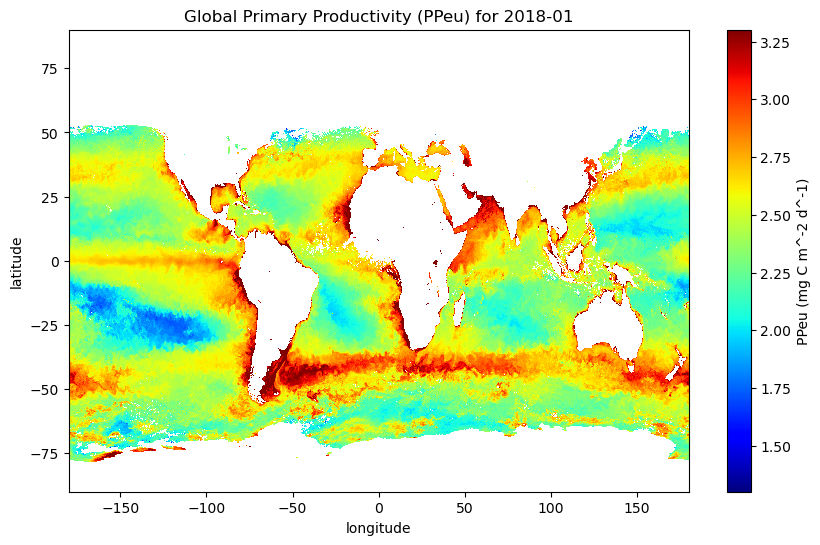

In [16]:
plot_PPeu(
    lon_grid,
    lat_grid,
    productivity,
    title=f"Global Primary Productivity (PPeu) for {(current_date - relativedelta(month=1)).strftime('%Y-%m')}",
)

## Plot SST

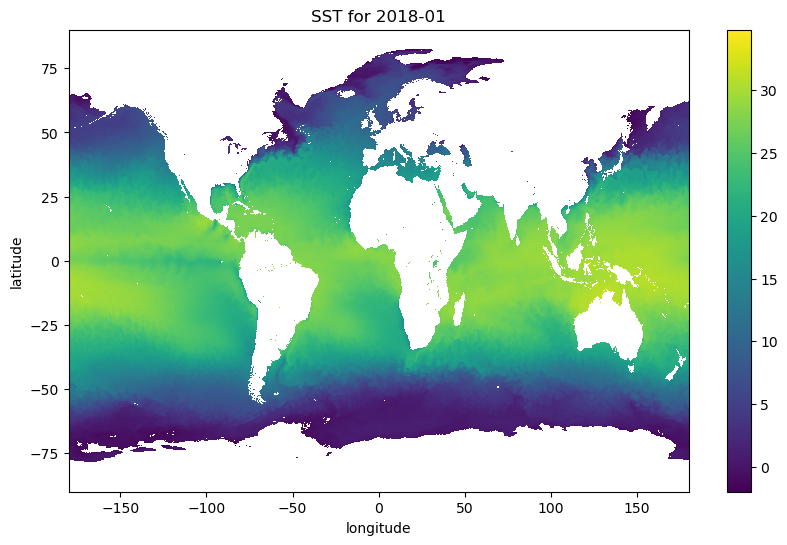

In [17]:
plot_globe(
    lon_grid,
    lat_grid,
    sea_surface_temp,
    title=f"SST for {(current_date - relativedelta(month=1)).strftime('%Y-%m')}",
)

## Verify $P_{opt}^b$
### Plotting $P_{opt}^b$ as a function of SST

The plot should show a smooth curve reflecting how productivity peaks within a specific SST range (~20 degrees Celisus).

<function matplotlib.pyplot.show(close=None, block=None)>

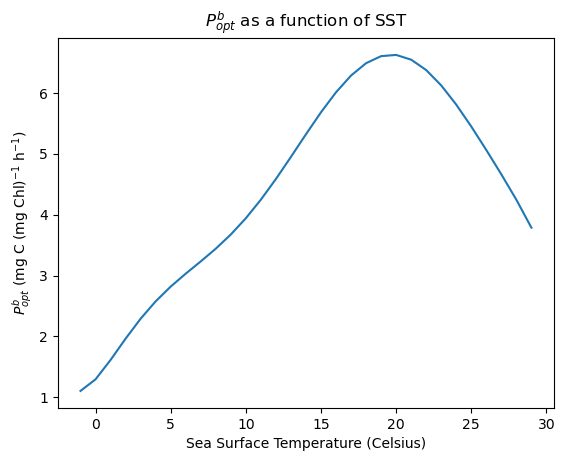

In [18]:
plt.plot(sst_list, PbOpt_plot)
plt.title("$P_{opt}^b$ as a function of SST")
plt.xlabel("Sea Surface Temperature (Celsius)")
plt.ylabel("$P_{opt}^b$ (mg C (mg Chl)$^{-1}$ h$^{-1}$)")
plt.show

## Plot CHL

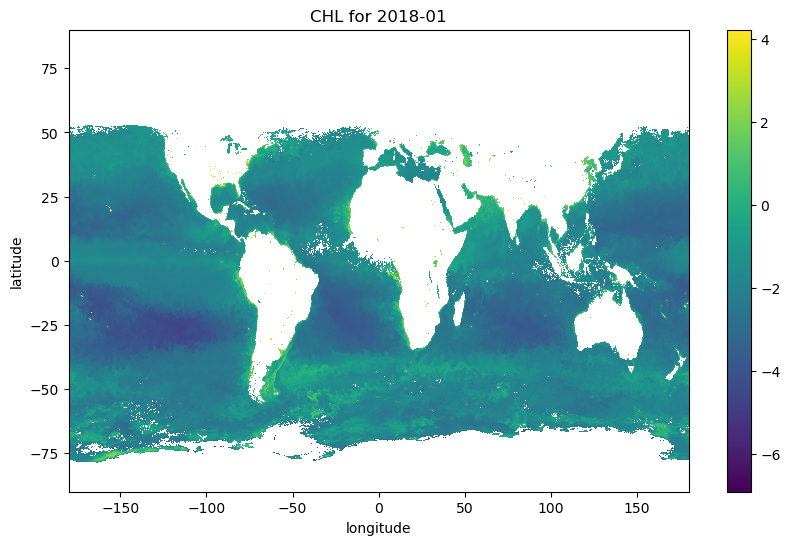

In [19]:
plot_globe(
    lon_grid,
    lat_grid,
    np.log(chlor_a),
    title=f"CHL for {(current_date - relativedelta(month=1)).strftime('%Y-%m')}",
)

## Plot PAR

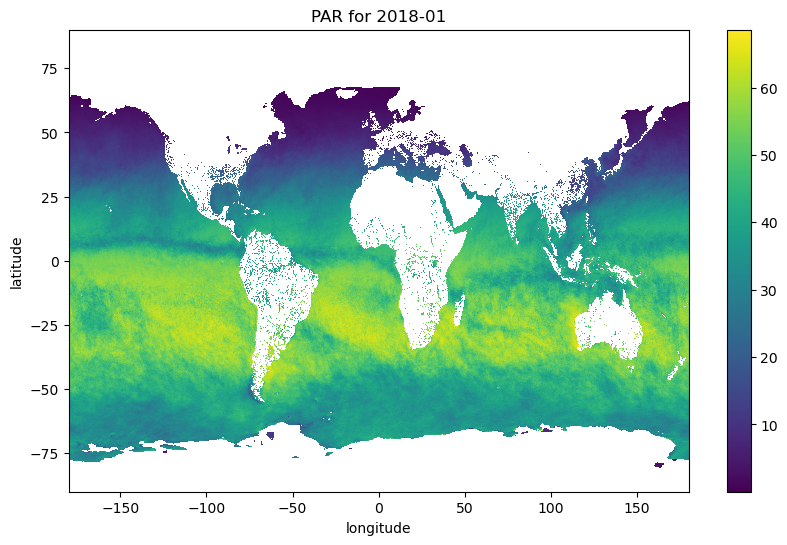

In [20]:
plot_globe(lon_grid, lat_grid, par, title=f"PAR for {(current_date - relativedelta(month=1)).strftime('%Y-%m')}")